# The Lotka-Volterra model
This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#submission folder
main_folder = Path("Baliti_Ocean Modelling Exercises")
figures_folder = main_folder / "Figures"
figures_folder.mkdir(parents=True, exist_ok=True)

This is the function containing the right hand side of the ODE system

In [3]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## Parameters and initial conditions

In [4]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## Time axis

In [5]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## Integration using the scipy ODE solver

In [6]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## Plot Fig. 9.3a

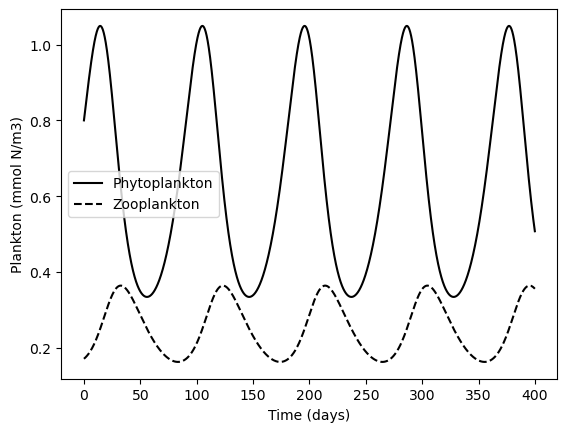

In [7]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

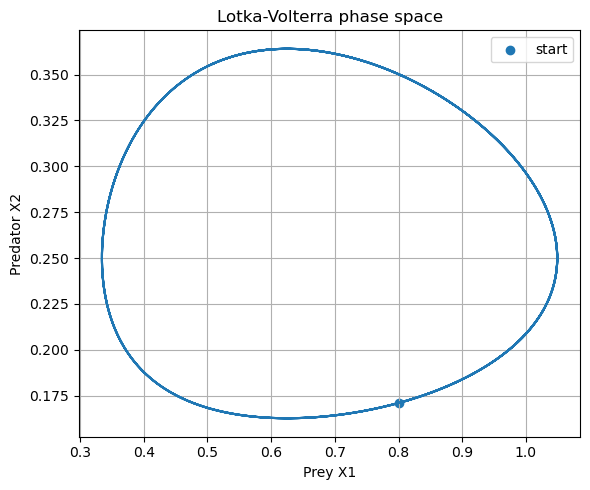

In [8]:
#panel b: phase-space plot
plt.figure(figsize=(6, 5))
plt.plot(y[:, 0], y[:, 1])
plt.scatter(y[0, 0], y[0, 1], label='start')
plt.xlabel('Prey X1')
plt.ylabel('Predator X2')
plt.title('Lotka-Volterra phase space')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder / 'ex3_phase_space.png', dpi=200)
plt.show()

2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

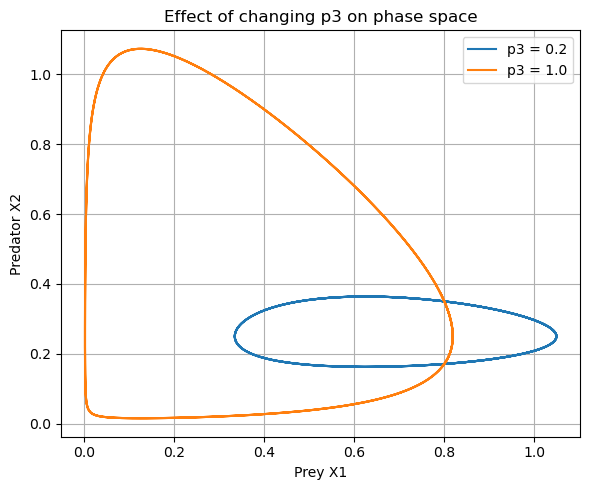

In [9]:
p_p3_1 = np.array([0.1, 0.4, 1.0, 0.05])
y_p3_1 = odeint(LV_pz, x0, t, args=(p_p3_1,))

plt.figure(figsize=(6, 5))
plt.plot(y[:, 0], y[:, 1], label='p3 = 0.2')
plt.plot(y_p3_1[:, 0], y_p3_1[:, 1], label='p3 = 1.0')
plt.xlabel('Prey X1')
plt.ylabel('Predator X2')
plt.title('Effect of changing p3 on phase space')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder / 'ex3_p3_comparison.png', dpi=200)
plt.show()

3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

In [10]:
#initial conditions from Figure 9.4
x0 = np.array([0.62, 0.25])
t0 = np.arange(0, 1100, 0.1)
y0 = odeint(LV_pz, x0, t0, args=(p,))

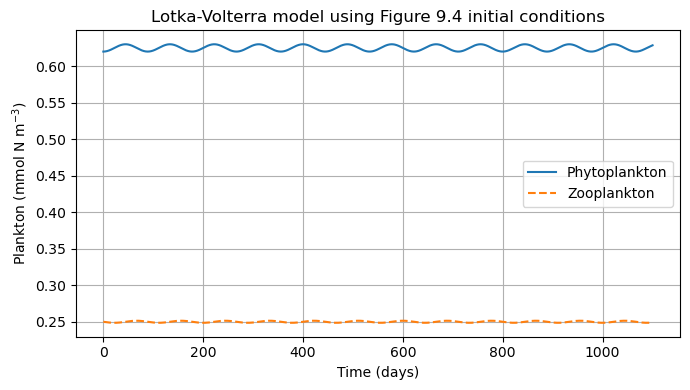

In [11]:
#time series for Figure 9.4 initial conditions
plt.figure(figsize=(7, 4))
plt.plot(t0, y0[:, 0], label='Phytoplankton')
plt.plot(t0, y0[:, 1], '--', label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N m$^{-3}$)')
plt.title('Lotka-Volterra model using Figure 9.4 initial conditions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder / 'ex3_fig94_timeseries.png', dpi=200)
plt.show()

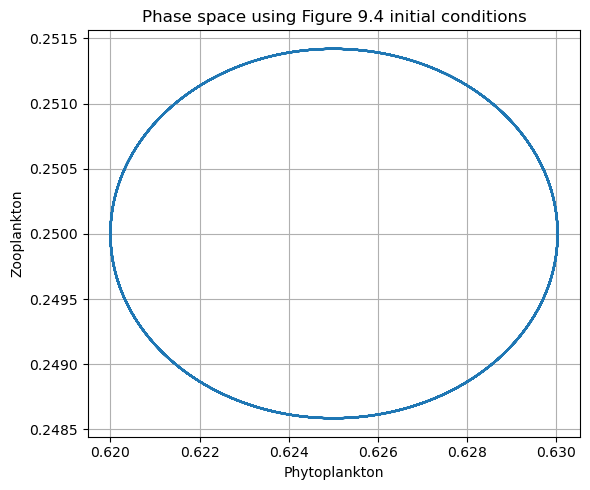

In [12]:
#phase space for Figure 9.4 initial conditions
plt.figure(figsize=(6, 5))
plt.plot(y0[:, 0], y0[:, 1])
plt.xlabel('Phytoplankton')
plt.ylabel('Zooplankton')
plt.title('Phase space using Figure 9.4 initial conditions')
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder / 'ex3_fig94_phase_space.png', dpi=200)
plt.show()

4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}

## Question 4

The result is different from the textbook figure because the Lotka-Volterra model is sensitive to the numerical method and initial conditions.